# 07 Eyre Peninsula: the workflow on a second area

The same steps on the Eyre Peninsula, eastern Gawler Craton. The grids
here are stored projected (GDA94 MGA zone 53) so nothing needs warping,
and the ocean is null, which exercises the NaN handling in every filter.

| grid | source | cell |
|---|---|---|
| `eyre_tmi.ers` | SA TMI 2011 state compilation, averaged from 93 m | 200 m |
| `eyre_grav.ers` | SA GRAVITY 2016 Bouguer anomaly | 400 m |

IGRF-13 for the peninsula at 2015.0: inclination -65.9, declination 6.7.

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from potfield import read_grid, write_grid, filters, transforms, spectrum, display

DATA = "../data"
OUT = "../outputs"
INC, DEC = -62.4, 7.5   # IGRF inclination, declination (deg) for the Frome area at 2015.0
plt.rcParams["figure.dpi"] = 90

Grid('eyre_tmi', 1485x1460, cell 200x200 m (~200x200 m), EPSG:28353, bounds W452874.5957 S6129351.7603 E744874.5957 N6426351.7603, units 'nT')
Grid('eyre_grav', 743x730, cell 400x400 m (~400x400 m), EPSG:28353, bounds W452904.6976 S6129097.0292 E744904.6976 N6426297.0292, units 'mGal')
null fraction TMI: 0.37


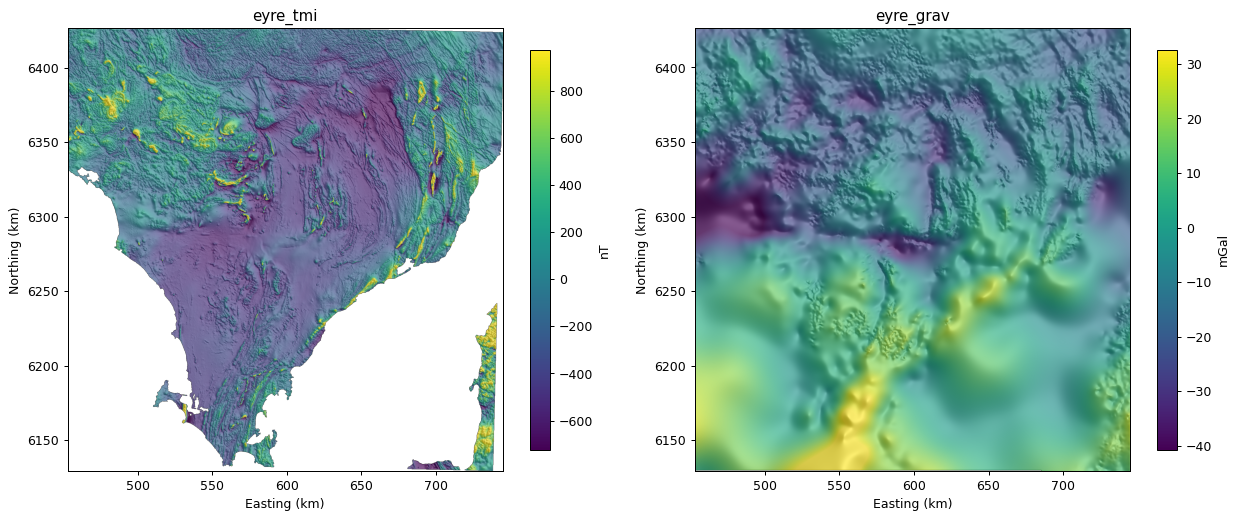

In [2]:
INC_E, DEC_E = -65.9, 6.7
tmi = read_grid(f"{DATA}/eyre_tmi.ers", units="nT")
grav = read_grid(f"{DATA}/eyre_grav.ers", units="mGal")
print(tmi); print(grav)
print("null fraction TMI:", round(np.isnan(tmi.values).mean(), 2))
fig, axes = display.compare([tmi, grav], ncols=2, cmap="viridis", clip=("pct", 1), shade={"azimuth": 45}, figsize_per=(7, 6))

## Reduction to the pole, derivatives

Run on the whole 200 m grid. With nulls over the sea the filters fill
them with the nearest value, filter, and put the nulls back; expect some
edge effect along the coast where the filled values are not real field.

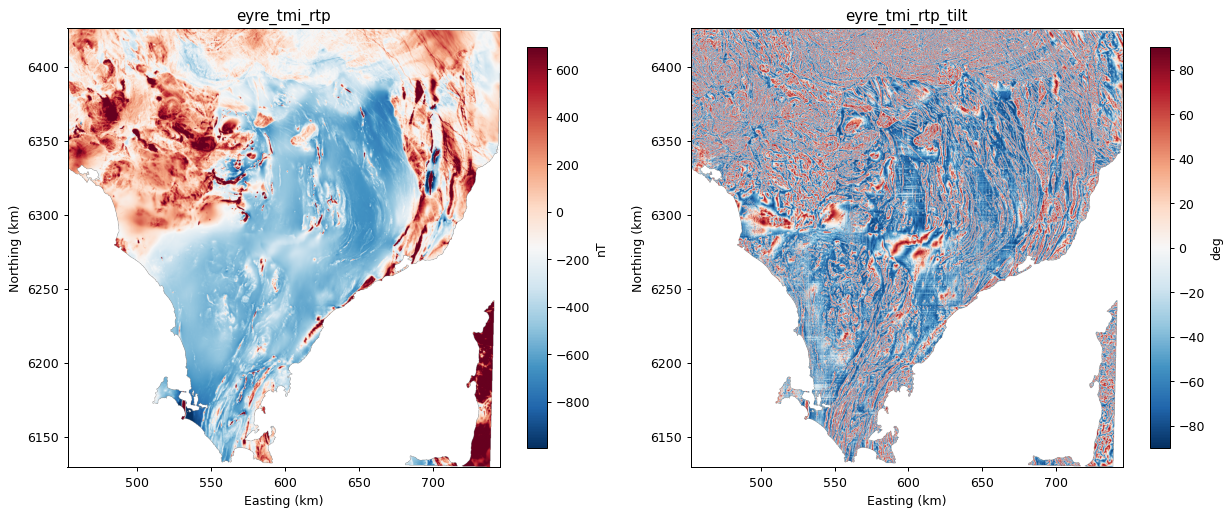

In [3]:
rtp = transforms.reduce_to_pole(tmi, INC_E, DEC_E)
tilt = filters.tilt_angle(rtp)
thdr = filters.total_horizontal_derivative(rtp)
fig, axes = display.compare([rtp, tilt], ncols=2, cmap="RdBu_r", clip=("std", 2.0), figsize_per=(7, 6))
axes[0, 1].images[0].set_clim(-90, 90)

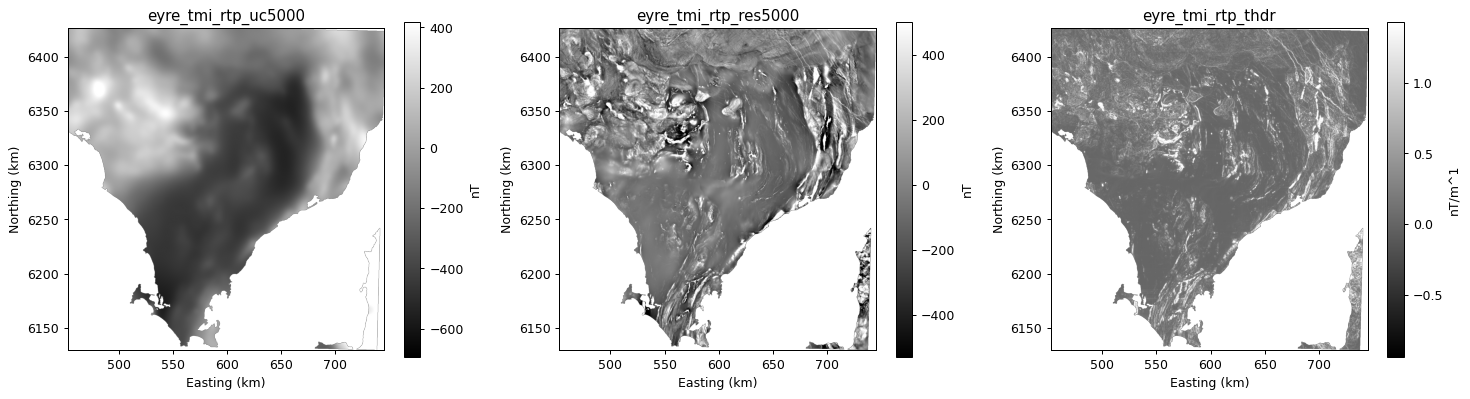

In [4]:
regional, residual = filters.regional_residual(rtp, 5000)
fig, axes = display.compare([regional, residual, thdr], ncols=3, cmap="gray", clip=("std", 2.0), figsize_per=(5.5, 5))

## Poisson analysis

Same recipe as notebook 06 scaled to this grid: pseudogravity against
gravity, low pass 6 km, regional 60 km, window 20 km. The band-passed
inputs first, then correlation and ratio masked where the window holds
little gravity signal or the fit is weak.

14% of the land area passes |r| > 0.6 and signal > 0.3


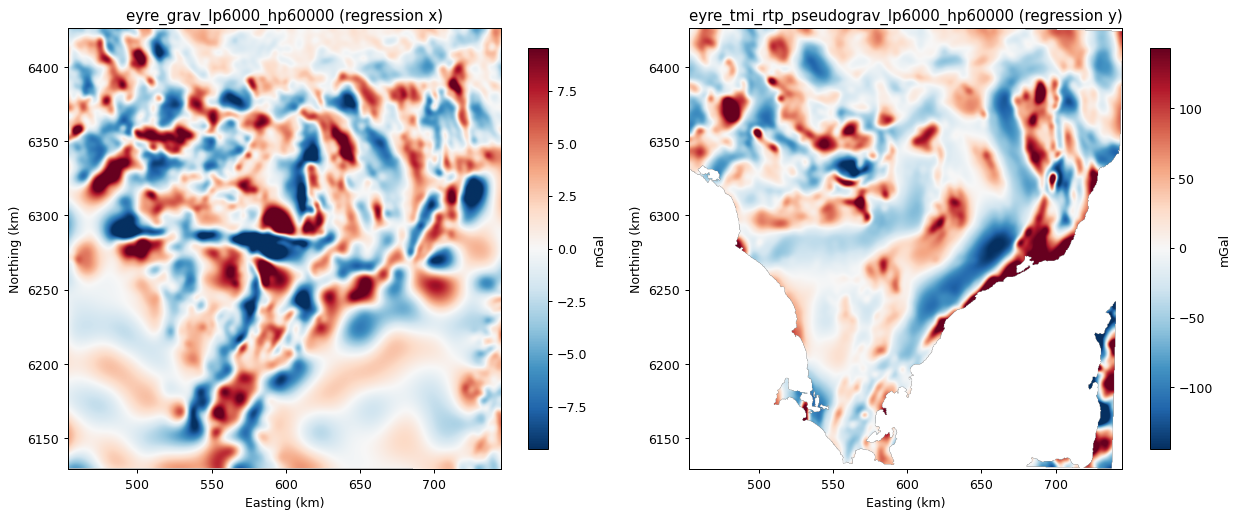

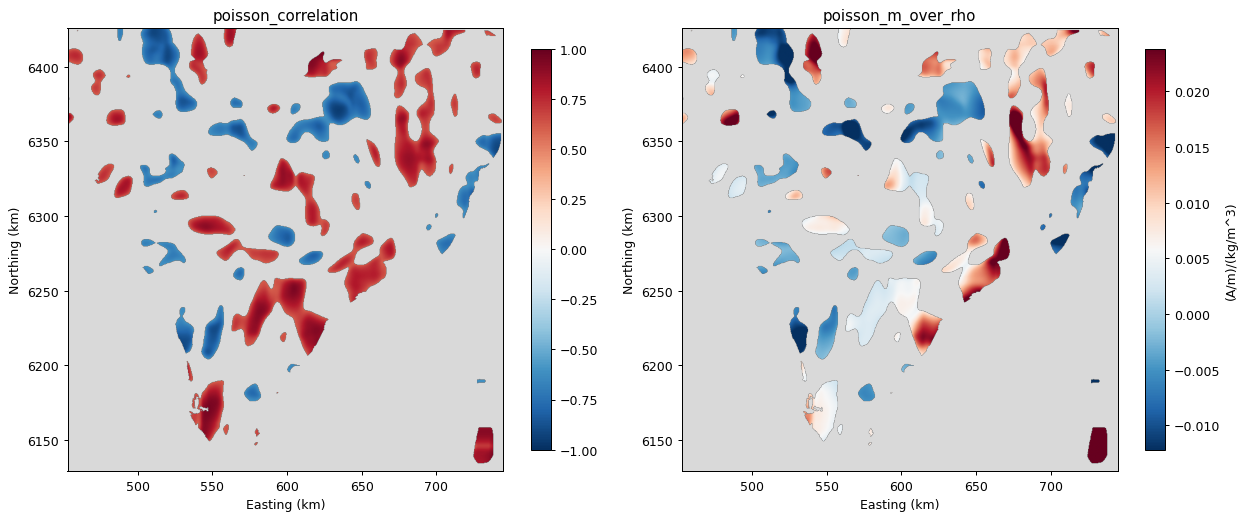

In [5]:
res = transforms.poisson_analysis(grav, rtp, magnetics_is_rtp=True, mode="pseudogravity",
                                  lowpass_wavelength=6000, regional_wavelength=60000, window_m=20000)
fig, axes = display.compare([res["x"], res["y"]], ncols=2, cmap="RdBu_r", clip=("std", 2.5), figsize_per=(7, 6))
r = res["correlation"].values
keep = (np.abs(r) > 0.6) & (res["signal"].values > 0.3)
corr = res["correlation"].with_values(np.where(keep, r, np.nan))
ratio = res["m_over_rho"].with_values(np.where(keep, res["m_over_rho"].values, np.nan))
fig, axes = display.compare([corr, ratio], ncols=2, cmap="RdBu_r", clip=(-1, 1), figsize_per=(7, 6))
axes[0, 1].images[0].set_clim(*display.clip_limits(ratio.values, "pct", 5))
for ax in axes.ravel():
    ax.set_facecolor("0.85")
print(f"{np.nanmean(keep) * 100:.0f}% of the land area passes |r| > 0.6 and signal > 0.3")

## Spectral depth

The radial spectrum of the RTP grid over the whole peninsula.

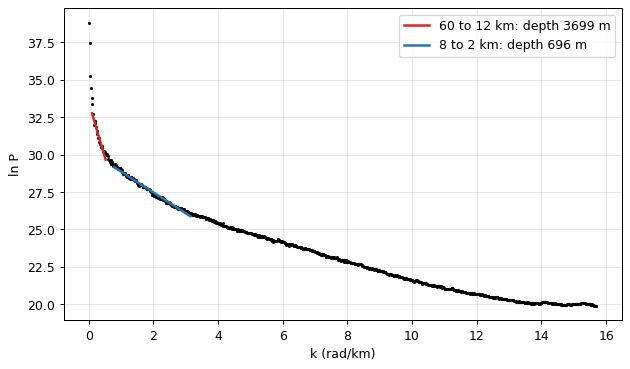

In [6]:
s = spectrum.radial_power_spectrum(rtp)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(s["k"] * 1e3, s["log_power"], ".", ms=3, color="k")
for (long_wl, short_wl, colour) in ((60000, 12000, "tab:red"), (8000, 2000, "tab:blue")):
    f = spectrum.depth_from_wavelengths(s, long_wl, short_wl)
    kk = np.array([2 * np.pi / long_wl, 2 * np.pi / short_wl])
    ax.plot(kk * 1e3, f["intercept"] + f["slope"] * kk, color=colour, lw=2,
            label=f"{long_wl/1e3:g} to {short_wl/1e3:g} km: depth {f['depth']:.0f} m")
ax.set_xlabel("k (rad/km)"); ax.set_ylabel("ln P"); ax.legend(); ax.grid(alpha=0.3)

## Export for a zone 53 Geotools database

The grids are already in MGA zone 53, so `epsg=28353` changes nothing.
Passing `epsg=28354` instead would warp them to zone 54 on the way out.

In [7]:
import os
os.makedirs(OUT, exist_ok=True)
for grid, name in ((rtp, "eyre_rtp"), (tilt, "eyre_tilt"), (res["correlation"], "eyre_poisson_correlation")):
    print(write_grid(grid, f"{OUT}/{name}.grd", epsg=28353))
print(write_grid(tilt, f"{OUT}/eyre_tilt.asc", epsg=28353))

..\outputs\eyre_rtp.grd


..\outputs\eyre_tilt.grd


..\outputs\eyre_poisson_correlation.grd


..\outputs\eyre_tilt.asc
